#  컬러 이미지 모델링

* 본 파일은 GPU 런타임으로 연결됩니다.
* 경우에 따라서는 GPU 연결이 원활하지 않을 수도 있습니다.

## 1.환경준비

### (1) 라이브러리 로딩

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as rd

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Input
from keras.backend import clear_session
from keras.optimizers import Adam
from keras.datasets import cifar10

* 함수 만들기

In [2]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err')
    plt.plot(history['val_loss'], label='val_err')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (2) 데이터로딩

![fashion class](https://datasets.activeloop.ai/wp-content/uploads/2022/09/CIFAR-10-dataset-Activeloop-Platform-visualization-image-1.webp)

In [3]:
# cifar10 데이터셋 불러오기
(x_train, y_train), (x_val, y_val) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:
x_train.shape, y_train.shape

((50000, 32, 32, 3), (50000, 1))

In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

## 2 데이터 살펴보기

In [6]:
y_train[1].item()

9

truck


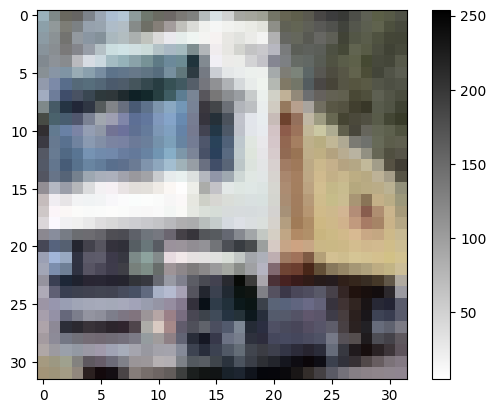

In [7]:
# 아래 숫자를 바꿔가며 화면에 그려 봅시다.
n = 1

print(class_names[y_train[1].item()])
plt.figure()
plt.imshow(x_train[n], cmap=plt.cm.binary)
plt.colorbar()
plt.show()

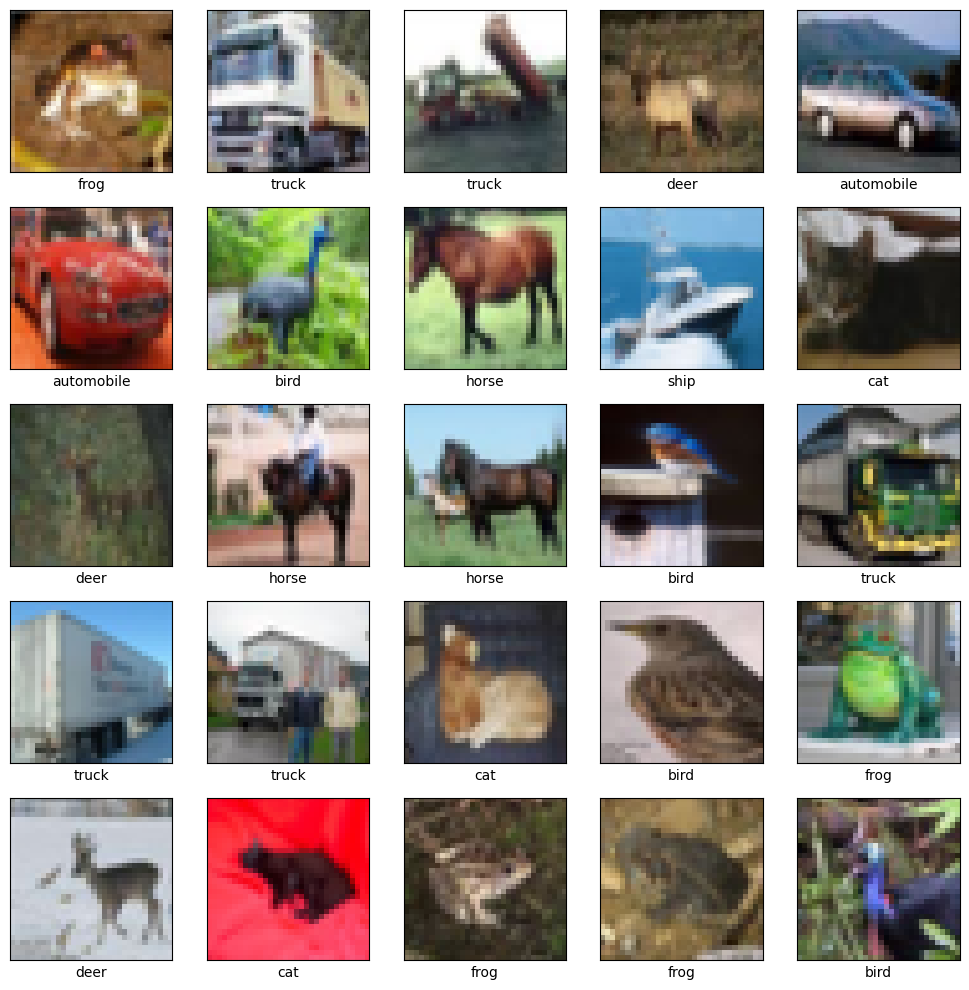

In [8]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i].item()])
plt.tight_layout()
plt.show()

## 3.데이터 준비

* CNN은 3차원 구조의 이미지(데이터셋은 4차원)를 입력해야 합니다.(input_shape)

In [9]:
x_train.shape, x_val.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

* Scaling : Min-Max
    * 0-255 값으로 되어 있는 데이터를 0-1사이 값으로 변환
    * x_train, x_test를 그냥 255로 나누면 됨

In [10]:
x_train = x_train / 255.
x_test = x_val / 255.

## 4.CNN 모델링

* 아래 그림의 구조대로 모델을 설계하고 학습해 봅시다.
* learning_rate = 0.0001

In [11]:
clear_session()

model = Sequential([Input(shape = (32, 32, 3)),
                    Conv2D(32, kernel_size=3, padding='same', activation ='relu'), # strides = 1 기본값
                    MaxPooling2D(pool_size = 2),  # strides = pool_size 기본값
                    Conv2D(64, kernel_size = 3, padding='same', activation = 'relu'),
                    MaxPooling2D(pool_size = 2),
                    Flatten(),
                    Dense(128, activation = 'relu'),
                    Dense(10, activation = 'softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy')

history = model.fit(x_train, y_train, epochs = 20,
                    validation_split=0.2).history

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 1.9362 - val_loss: 1.5363
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.4649 - val_loss: 1.3868
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.3203 - val_loss: 1.2781
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.2371 - val_loss: 1.2121
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.1708 - val_loss: 1.2185
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.1147 - val_loss: 1.1374
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.0820 - val_loss: 1.1080
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.0393 - val_loss: 1.0861
Epoch 9/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.9915 - val_loss: 1.0633
Epoch 10/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.9674 - val_loss: 1.0281
Epoch 11/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.9346 - val_loss: 1.0192
Epoch 12/20
1250/1250 ━━━━━━━

* 학습결과 그래프

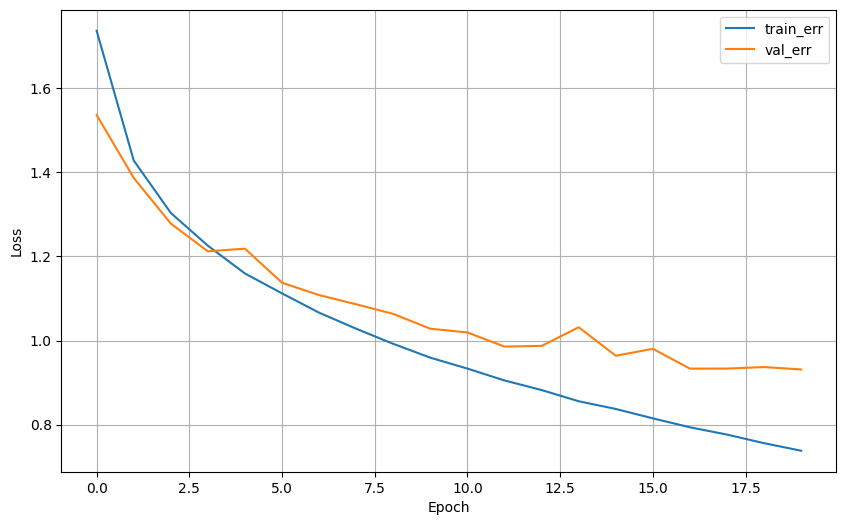

In [13]:
dl_history_plot(history)

* 예측 및 평가

In [14]:
pred = model.predict(x_val)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [15]:
pred_1 = pred.argmax(axis=1)

In [16]:
print(accuracy_score(y_val,pred_1))
print('-'*60)
print(confusion_matrix(y_val, pred_1))
print('-'*60)
print(classification_report(y_val, pred_1))

0.5997
------------------------------------------------------------
[[762  20  12  29   2   4   4  26  60  81]
 [ 26 749   0   8   0   5   4   8  15 185]
 [119  17 212 152  34 124  70 198  21  53]
 [ 33  25   9 480   7 165  38 122  25  96]
 [ 60  17  16 149 236  90  43 335  19  35]
 [ 25  10   7 185  10 528   9 172  10  44]
 [ 16  28   8 109  10  60 636  50  23  60]
 [ 15   5   1  23   5  37   1 852   4  57]
 [114  61   1  11   0   4   1  18 711  79]
 [ 28  82   0  11   0   4   2  19  23 831]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.64      0.76      0.69      1000
           1       0.74      0.75      0.74      1000
           2       0.80      0.21      0.33      1000
           3       0.41      0.48      0.45      1000
           4       0.78      0.24      0.36      1000
           5       0.52      0.53      0.52      1000
           6       0.79      0.64      0.70      1000
       

## 5.실습 : 성능을 더 높이기 위한 모델링

In [17]:
clear_session()

model2 = Sequential([Input(shape = (32, 32, 3)),
                        Conv2D(32, kernel_size=3, padding='same', activation ='relu'), # strides = 1 기본값
                        MaxPooling2D(pool_size = 2),  # strides = pool_size 기본값
                        Conv2D(64, kernel_size = 3, padding='same', activation = 'relu'),
                        MaxPooling2D(pool_size = 2),
                        Conv2D(128, kernel_size = 3, padding='same', activation = 'relu'),
                        MaxPooling2D(pool_size = 2),
                        Flatten(),
                        Dense(512, activation = 'relu'),
                        Dense(128, activation = 'relu'),
                        Dense(10, activation = 'softmax')
])

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,209,290 (4.61 MB)

 Trainable params: 1,209,290 (4.61 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model2.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy')

history = model2.fit(x_train, y_train, epochs = 20,
                    validation_split=0.2).history

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 1.9315 - val_loss: 1.4635
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.3977 - val_loss: 1.3231
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.2261 - val_loss: 1.2305
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.1147 - val_loss: 1.1003
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.0337 - val_loss: 1.0229
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.9484 - val_loss: 1.0056
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.8887 - val_loss: 0.9815
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.8350 - val_loss: 0.9122
Epoch 9/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.7853 - val_loss: 0.9115
Epoch 10/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.7493 - val_loss: 0.8906
Epoch 11/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.6890 - val_loss: 0.9106
Epoch 12/20
1250/1250 ━━━━━━━

In [19]:
pred = model2.predict(x_val)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [20]:
pred_1 = pred.argmax(axis=1)

In [21]:
print(accuracy_score(y_val,pred_1))
print('-'*60)
print(confusion_matrix(y_val, pred_1))
print('-'*60)
print(classification_report(y_val, pred_1))

0.6367
------------------------------------------------------------
[[883  18   3   4   2   2   2  10  26  50]
 [ 30 879   0   0   0   2   1   3  10  75]
 [242  24 345  77  25  99  34 106  15  33]
 [114  42  19 360  19 204  32 116  18  76]
 [137  17  40  72 306  88  34 259  17  30]
 [ 61  21  11 103  11 626   8 114  13  32]
 [103  38  18  70  10  59 598  40  16  48]
 [ 53   8   6  16   7  41   1 832   3  33]
 [153  51   1   6   0   4   1   6 724  54]
 [ 50 102   1   4   0   5   2   9  13 814]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.48      0.88      0.62      1000
           1       0.73      0.88      0.80      1000
           2       0.78      0.34      0.48      1000
           3       0.51      0.36      0.42      1000
           4       0.81      0.31      0.44      1000
           5       0.55      0.63      0.59      1000
           6       0.84      0.60      0.70      1000
       